# ML Regime Classification for Bitcoin Volatility

**Date:** 2026-04-03

This notebook applies unsupervised and supervised machine learning to classify BTC volatility regimes:

1. **HMM** — Hidden Markov Model for regime detection
2. **Markov-Switching** — Statsmodels parametric regime-switching model
3. **Supervised ML** — Random Forest & XGBoost trained on MS regime labels
4. **Regime Prediction** — Can we predict regime switches 1 day ahead?

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from hmmlearn.hmm import GaussianHMM
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

from data_loader import load_from_csv, get_btc_returns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("All imports loaded successfully.")

All imports loaded successfully.


## Part 1: Data Loading & Preparation

In [2]:
# Load dataset
df = load_from_csv()
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Range: {df.index.min().date()} \u2192 {df.index.max().date()}")

# Raw BTC log returns
btc_ret_raw = df["dln_btc"].dropna()

# Scaled returns (x100) for GARCH-family models
btc_ret = get_btc_returns(df)

print(f"\nBTC returns: {len(btc_ret_raw)} observations")
print(f"Mean: {btc_ret_raw.mean():.6f}, Std: {btc_ret_raw.std():.4f}")

Dataset: 4054 rows, 30 columns
Range: 2015-01-05 → 2026-02-09

BTC returns: 4054 observations
Mean: 0.001377, Std: 0.0354


In [3]:
# Prepare feature matrix for ML
feat = df[["dln_btc", "dln_gold", "d_vix", "dln_volume", "dln_n_tx", "dln_cpi"]].copy()

# Lagged returns (1, 5, 21 days)
for lag in [1, 5, 21]:
    feat[f"ret_lag_{lag}"] = df["dln_btc"].shift(lag)

# Rolling volatility (5, 21, 63 days)
for window in [5, 21, 63]:
    feat[f"rvol_{window}"] = df["dln_btc"].rolling(window).std()

feat = feat.dropna()
print(f"Feature matrix: {feat.shape}")
print(f"Columns: {feat.columns.tolist()}")

Feature matrix: (3992, 12)
Columns: ['dln_btc', 'dln_gold', 'd_vix', 'dln_volume', 'dln_n_tx', 'dln_cpi', 'ret_lag_1', 'ret_lag_5', 'ret_lag_21', 'rvol_5', 'rvol_21', 'rvol_63']


## Part 2: HMM Regime Detection

**Hidden Markov Models** assume the observed returns are generated by a latent (hidden) Markov chain switching between discrete states. Each state has its own mean and variance — making HMM a natural fit for volatility regime detection.

Key differences from Markov-Switching regression:
- **HMM** is fully unsupervised — no parametric model for returns, just Gaussian emissions
- **MS-Regression** nests regime switching inside a regression framework with explicit likelihood

In [4]:
# Fit 2-state Gaussian HMM on BTC returns
X_hmm = btc_ret_raw.values.reshape(-1, 1)

hmm_model = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=200,
    random_state=42,
)
hmm_model.fit(X_hmm)

# Predict hidden states
hmm_states = hmm_model.predict(X_hmm)
hmm_proba = hmm_model.predict_proba(X_hmm)

# Sort regimes so that regime 0 = calm (lower variance)
state_vols = [btc_ret_raw.values[hmm_states == s].std() for s in range(2)]
if state_vols[0] > state_vols[1]:
    # Swap labels
    hmm_states = 1 - hmm_states
    hmm_proba = hmm_proba[:, ::-1]
    state_vols = state_vols[::-1]

hmm_labels = pd.Series(hmm_states, index=btc_ret_raw.index, name="hmm_regime")

print("HMM Regime Statistics:")
print("=" * 50)
for s in range(2):
    mask = hmm_labels == s
    ret_s = btc_ret_raw[mask]
    label = "Calm" if s == 0 else "Turbulent"
    # Duration: average consecutive run length
    changes = hmm_labels.diff().ne(0).cumsum()
    durations = changes[mask].value_counts()
    avg_dur = durations.mean()
    print(f"  Regime {s} ({label}):")
    print(f"    Days:     {mask.sum()} ({mask.mean():.1%})")
    print(f"    Mean:     {ret_s.mean():.6f}")
    print(f"    Std:      {ret_s.std():.4f}")
    print(f"    Avg duration: {avg_dur:.1f} days")
    print()

print(f"Log-likelihood: {hmm_model.score(X_hmm):.2f}")

HMM Regime Statistics:
  Regime 0 (Calm):
    Days:     2809 (69.3%)
    Mean:     0.001677
    Std:      0.0174
    Avg duration: 20.2 days

  Regime 1 (Turbulent):
    Days:     1245 (30.7%)
    Mean:     0.000699
    Std:      0.0584
    Avg duration: 9.0 days

Log-likelihood: 8488.96


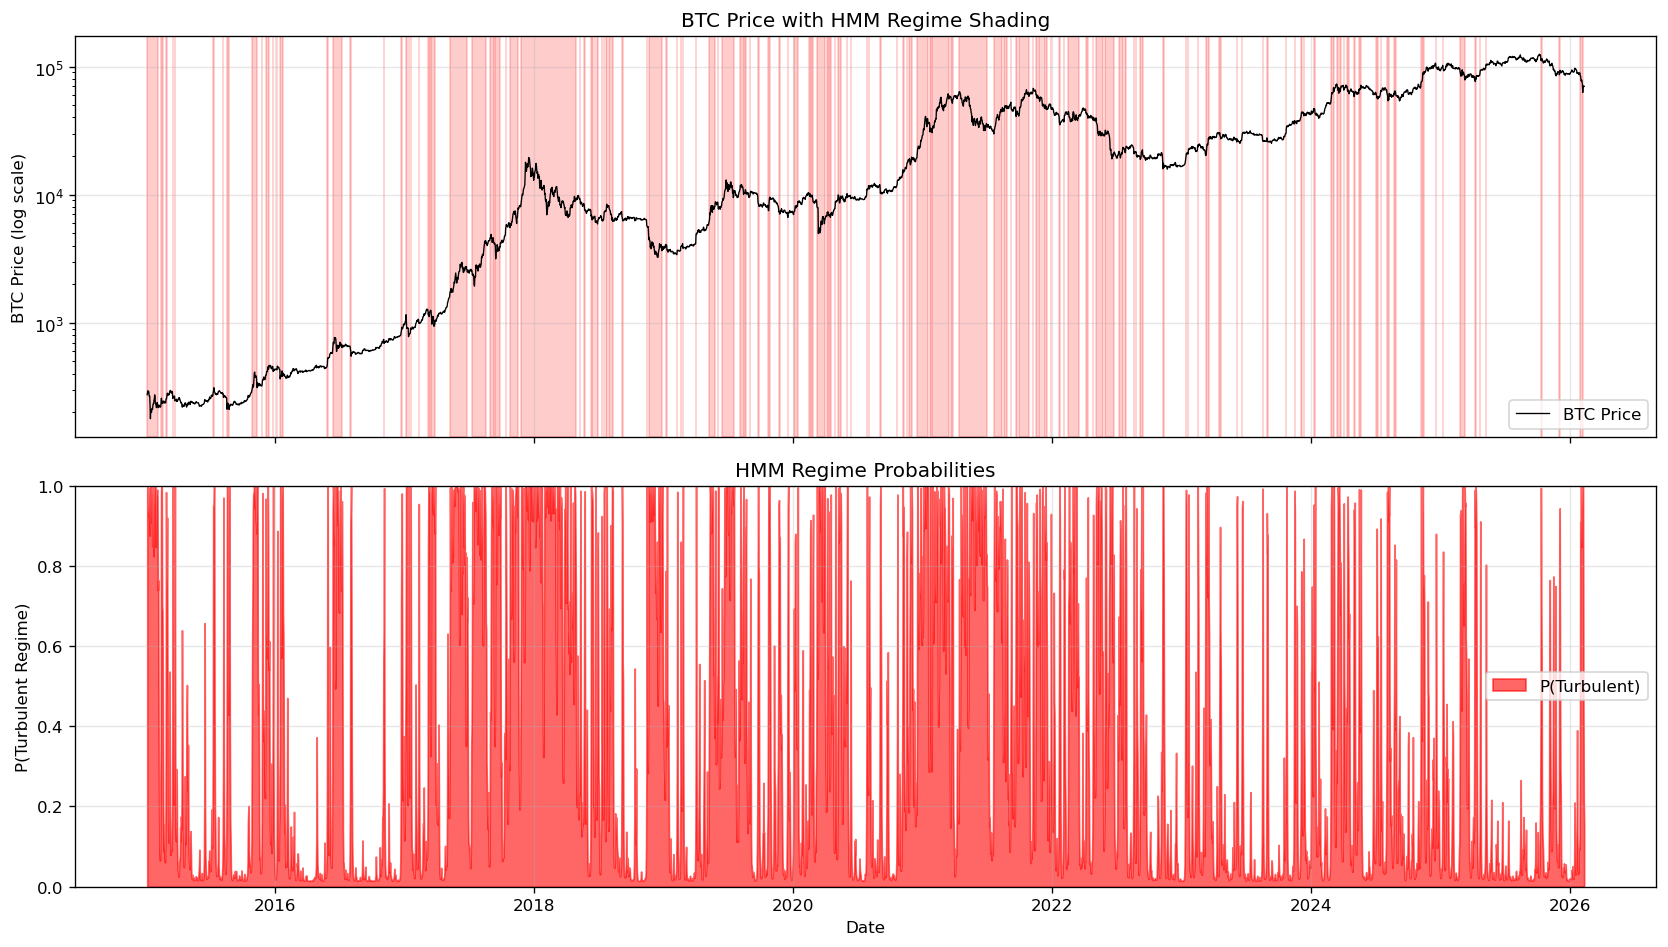

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: BTC price with regime shading
ax1 = axes[0]
ax1.plot(df["btc"].loc[btc_ret_raw.index], color="black", linewidth=0.8, label="BTC Price")
ax1.set_yscale("log")
ax1.set_ylabel("BTC Price (log scale)")
ax1.set_title("BTC Price with HMM Regime Shading")

# Shade turbulent regimes
turbulent = hmm_labels == 1
starts = btc_ret_raw.index[turbulent & ~turbulent.shift(1, fill_value=False)]
ends = btc_ret_raw.index[turbulent & ~turbulent.shift(-1, fill_value=False)]
for s, e in zip(starts, ends):
    ax1.axvspan(s, e, alpha=0.2, color="red")
ax1.legend()

# Bottom: Regime probabilities
ax2 = axes[1]
ax2.fill_between(btc_ret_raw.index, hmm_proba[:, 1], alpha=0.6, color="red", label="P(Turbulent)")
ax2.set_ylabel("P(Turbulent Regime)")
ax2.set_xlabel("Date")
ax2.set_title("HMM Regime Probabilities")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.show()

## Part 3: Compare HMM vs Markov-Switching

We fit a Markov-Switching regression model (Hamilton, 1989) with switching variance on the same BTC return series, then compare the two approaches.

In [6]:
# Fit Markov-Switching regression with switching variance
ms_model = MarkovRegression(
    btc_ret_raw,
    k_regimes=2,
    switching_variance=True,
)
ms_result = ms_model.fit(disp=False)
print(ms_result.summary())

                        Markov Switching Model Results                        
Dep. Variable:                dln_btc   No. Observations:                 4054
Model:               MarkovRegression   Log Likelihood                8488.568
Date:                Fri, 03 Apr 2026   AIC                         -16965.137
Time:                        22:56:15   BIC                         -16927.292
Sample:                    01-05-2015   HQIC                        -16951.731
                         - 02-09-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.000      4.104      0.000       0.001       0.002
sigma2         0.0003   1.87e-05     14.925      0.0

In [7]:
# Extract MS smoothed probabilities and regime labels
ms_proba = ms_result.smoothed_marginal_probabilities

# Regime assignment: higher variance = turbulent (regime 1)
# Check which MS regime has higher variance
ms_labels_raw = ms_proba.iloc[:, 1] > 0.5
regime_0_vol = btc_ret_raw[~ms_labels_raw].std()
regime_1_vol = btc_ret_raw[ms_labels_raw].std()

if regime_0_vol > regime_1_vol:
    ms_regime = (~ms_labels_raw).astype(int)
    ms_turbulent_prob = ms_proba.iloc[:, 0]
else:
    ms_regime = ms_labels_raw.astype(int)
    ms_turbulent_prob = ms_proba.iloc[:, 1]

ms_regime.name = "ms_regime"

# Cohen's kappa agreement
kappa = cohen_kappa_score(hmm_labels, ms_regime)
print(f"Cohen's Kappa (HMM vs MS): {kappa:.3f}")
if kappa > 0.6:
    print("  \u2192 Substantial agreement")
elif kappa > 0.4:
    print("  \u2192 Moderate agreement")
else:
    print("  \u2192 Fair or poor agreement")

# Confusion matrix
cm = confusion_matrix(hmm_labels, ms_regime)
print(f"\nConfusion Matrix (rows=HMM, cols=MS):")
print(pd.DataFrame(cm,
    index=["HMM_Calm", "HMM_Turbulent"],
    columns=["MS_Calm", "MS_Turbulent"]))

# Agreement rate
agree = (hmm_labels.values == ms_regime.values).mean()
print(f"\nAgreement rate: {agree:.1%}")

Cohen's Kappa (HMM vs MS): 0.881
  → Substantial agreement

Confusion Matrix (rows=HMM, cols=MS):
               MS_Calm  MS_Turbulent
HMM_Calm          2667           142
HMM_Turbulent       67          1178

Agreement rate: 94.8%


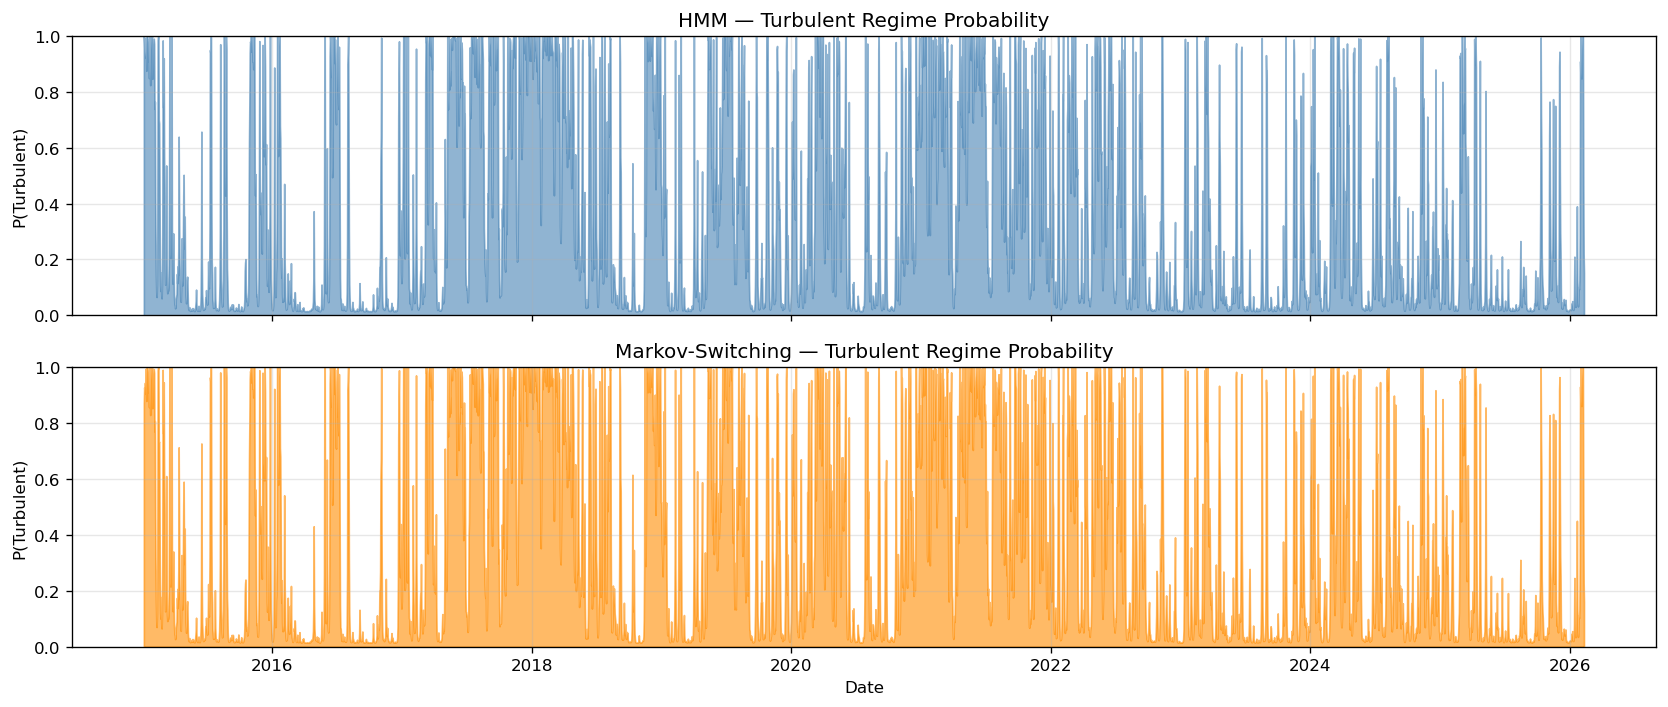

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1 = axes[0]
ax1.fill_between(btc_ret_raw.index, hmm_proba[:, 1], alpha=0.6, color="steelblue")
ax1.set_ylabel("P(Turbulent)")
ax1.set_title("HMM \u2014 Turbulent Regime Probability")
ax1.set_ylim(0, 1)

ax2 = axes[1]
ax2.fill_between(btc_ret_raw.index, ms_turbulent_prob, alpha=0.6, color="darkorange")
ax2.set_ylabel("P(Turbulent)")
ax2.set_title("Markov-Switching \u2014 Turbulent Regime Probability")
ax2.set_ylim(0, 1)
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

## Part 4: Feature Engineering for Supervised Learning

We use the **Markov-Switching smoothed regime labels** as ground truth for supervised classification. The MS model provides a principled, model-based partition of calm vs turbulent periods.

**Important:** Train/test split is temporal (80/20), NOT random shuffle — this is time series data.

In [9]:
# Ground truth: MS regime labels (turbulent = 1)
y = ms_regime.copy()

# Build feature set aligned with regime labels
features = pd.DataFrame(index=btc_ret_raw.index)

# Lagged returns
for lag in [1, 5, 21]:
    features[f"ret_lag_{lag}d"] = btc_ret_raw.shift(lag)

# Rolling volatility
for window in [5, 21, 63]:
    features[f"rvol_{window}d"] = btc_ret_raw.rolling(window).std()

# Rolling skewness (21d)
features["rskew_21d"] = btc_ret_raw.rolling(21).skew()

# Macro / on-chain features
features["d_vix"] = df["d_vix"]
features["dln_gold"] = df["dln_gold"]
features["dln_volume"] = df["dln_volume"]
features["dln_n_tx"] = df["dln_n_tx"]

# Align and drop NaN
common_idx = features.dropna().index.intersection(y.index)
X = features.loc[common_idx]
y = y.loc[common_idx]

print(f"Feature matrix: {X.shape}")
print(f"Target distribution:\n{y.value_counts().rename({0: 'Calm', 1: 'Turbulent'})}")
print(f"\nFeatures: {X.columns.tolist()}")

Feature matrix: (3992, 11)
Target distribution:
ms_regime
Calm         2715
Turbulent    1277
Name: count, dtype: int64

Features: ['ret_lag_1d', 'ret_lag_5d', 'ret_lag_21d', 'rvol_5d', 'rvol_21d', 'rvol_63d', 'rskew_21d', 'd_vix', 'dln_gold', 'dln_volume', 'dln_n_tx']


In [10]:
# Temporal train/test split (80/20 \u2014 NO shuffle)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} samples ({X_train.index.min().date()} \u2192 {X_train.index.max().date()})")
print(f"Test:  {X_test.shape[0]} samples ({X_test.index.min().date()} \u2192 {X_test.index.max().date()})")
print(f"\nTrain regime distribution:\n{y_train.value_counts().rename({0: 'Calm', 1: 'Turbulent'})}")
print(f"\nTest regime distribution:\n{y_test.value_counts().rename({0: 'Calm', 1: 'Turbulent'})}")

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Train: 3193 samples (2015-03-08 → 2023-12-03)
Test:  799 samples (2023-12-04 → 2026-02-09)

Train regime distribution:
ms_regime
Calm         2052
Turbulent    1141
Name: count, dtype: int64

Test regime distribution:
ms_regime
Calm         663
Turbulent    136
Name: count, dtype: int64


## Part 5: Random Forest & XGBoost Classification

In [11]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
)
rf.fit(X_train_sc, y_train)
rf_pred = rf.predict(X_test_sc)

print("=" * 60)
print("RANDOM FOREST \u2014 Classification Report")
print("=" * 60)
print(classification_report(y_test, rf_pred, target_names=["Calm", "Turbulent"]))

# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
)
xgb.fit(X_train_sc, y_train)
xgb_pred = xgb.predict(X_test_sc)

print("=" * 60)
print("XGBOOST \u2014 Classification Report")
print("=" * 60)
print(classification_report(y_test, xgb_pred, target_names=["Calm", "Turbulent"]))

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

        Calm       0.91      0.94      0.92       663
   Turbulent       0.64      0.53      0.58       136

    accuracy                           0.87       799
   macro avg       0.77      0.73      0.75       799
weighted avg       0.86      0.87      0.86       799



XGBOOST — Classification Report
              precision    recall  f1-score   support

        Calm       0.92      0.92      0.92       663
   Turbulent       0.60      0.62      0.61       136

    accuracy                           0.86       799
   macro avg       0.76      0.77      0.76       799
weighted avg       0.87      0.86      0.87       799



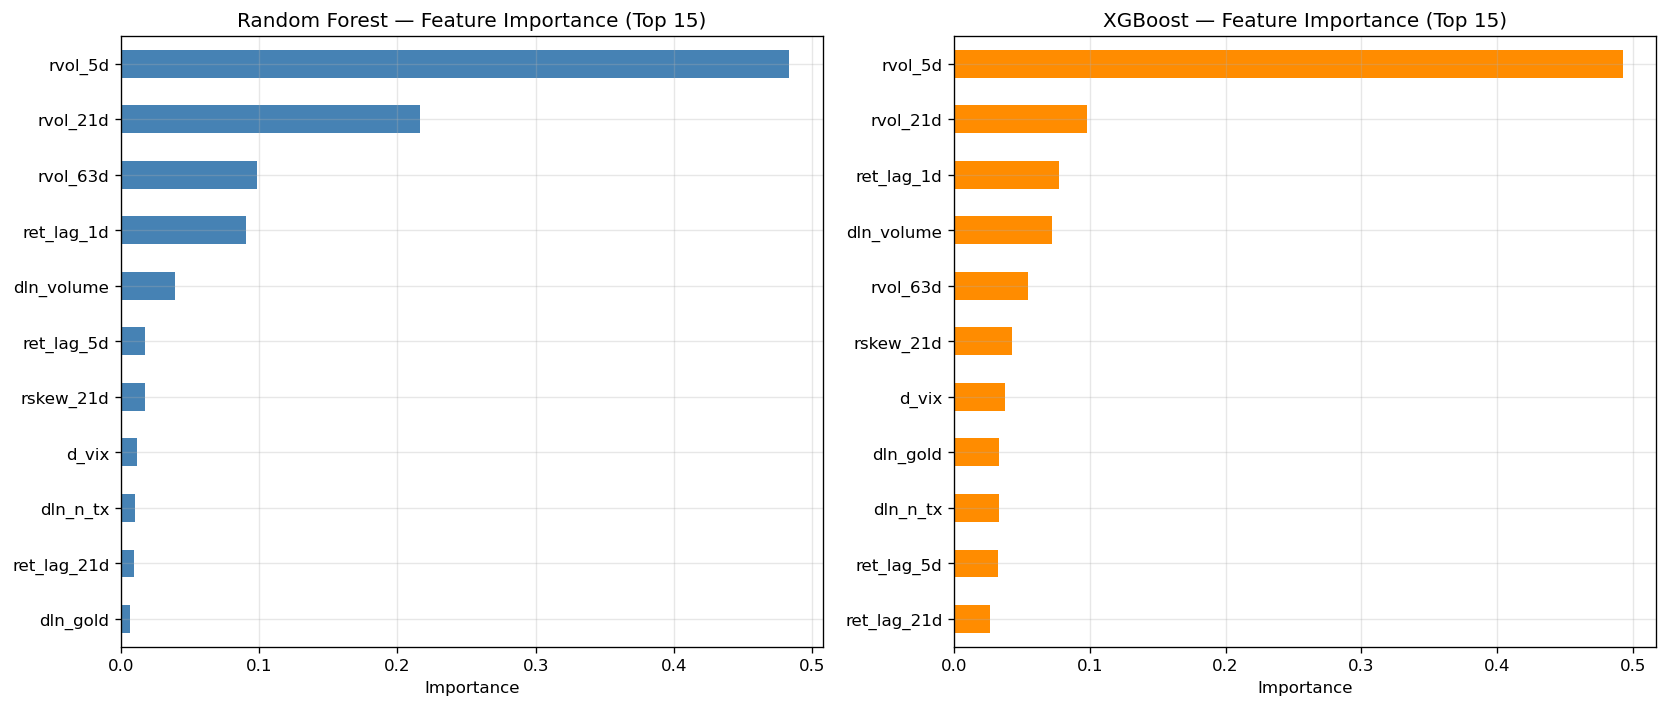

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

feature_names = X.columns.tolist()

# RF feature importance
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)
rf_imp.tail(15).plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Random Forest \u2014 Feature Importance (Top 15)")
axes[0].set_xlabel("Importance")

# XGB feature importance
xgb_imp = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=True)
xgb_imp.tail(15).plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("XGBoost \u2014 Feature Importance (Top 15)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [13]:
# Time-series cross-validation (5 folds)
tscv = TimeSeriesSplit(n_splits=5)

# Scale full feature matrix for CV
X_all_sc = scaler.fit_transform(X)

rf_cv = cross_val_score(rf, X_all_sc, y, cv=tscv, scoring="f1")
xgb_cv = cross_val_score(xgb, X_all_sc, y, cv=tscv, scoring="f1")

print("Time-Series Cross-Validation (F1 Score)")
print("=" * 50)
print(f"Random Forest:  {rf_cv.mean():.3f} \u00b1 {rf_cv.std():.3f}  (folds: {rf_cv.round(3)})")
print(f"XGBoost:        {xgb_cv.mean():.3f} \u00b1 {xgb_cv.std():.3f}  (folds: {xgb_cv.round(3)})")

Time-Series Cross-Validation (F1 Score)
Random Forest:  0.632 ± 0.078  (folds: [0.682 0.676 0.718 0.509 0.573])
XGBoost:        0.626 ± 0.074  (folds: [0.527 0.692 0.719 0.632 0.56 ])


## Part 6: Regime Prediction Evaluation

Key question: **Can ML predict regime switches 1 day ahead?**

This matters for practical risk management — if we can anticipate a transition to a turbulent regime, we can reduce exposure before the storm hits.

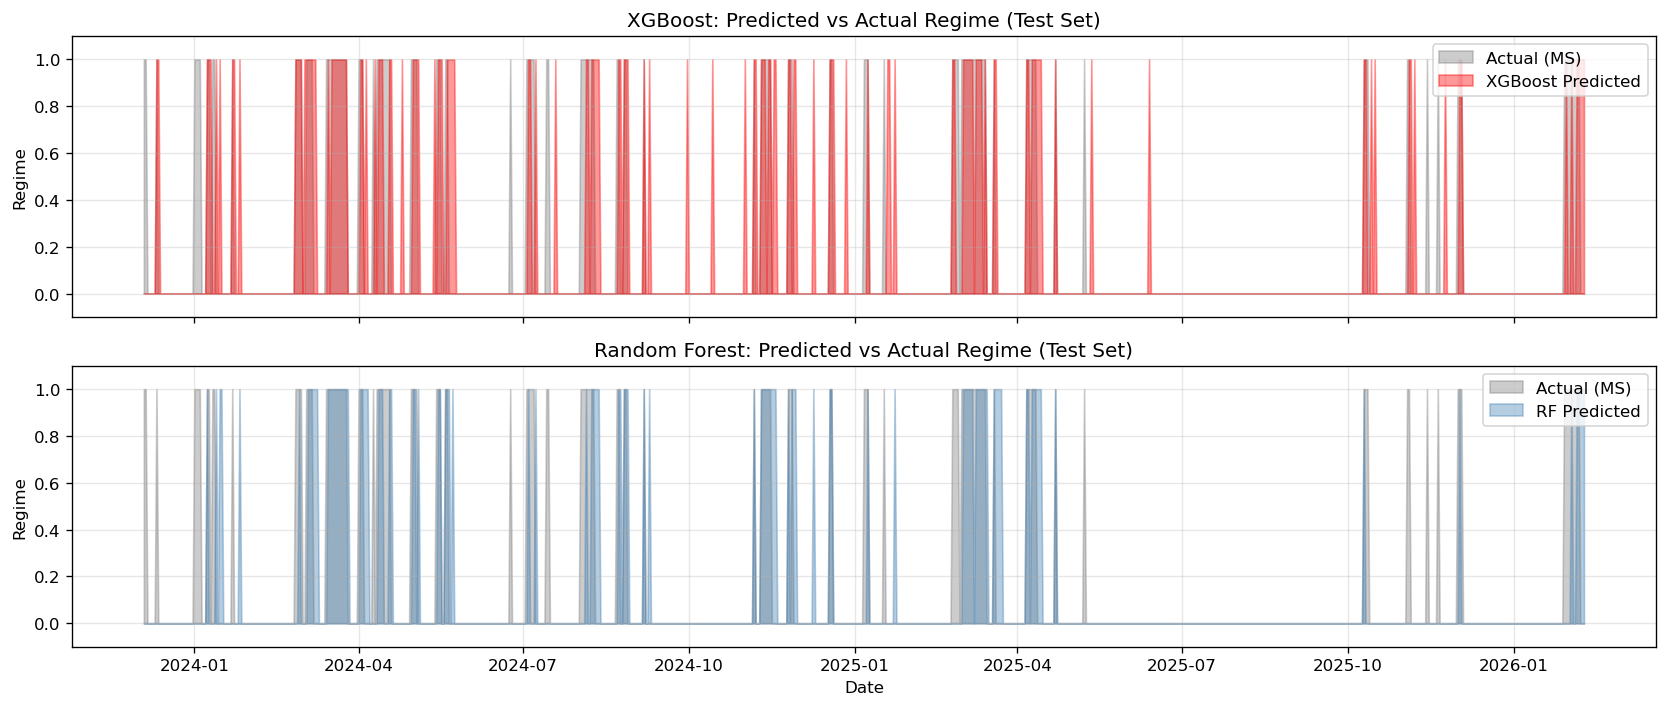

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# XGBoost predictions vs actual (test set)
test_dates = X_test.index

ax1 = axes[0]
ax1.fill_between(test_dates, y_test.values, alpha=0.4, color="gray", label="Actual (MS)")
ax1.fill_between(test_dates, xgb_pred, alpha=0.4, color="red", label="XGBoost Predicted")
ax1.set_ylabel("Regime")
ax1.set_title("XGBoost: Predicted vs Actual Regime (Test Set)")
ax1.legend(loc="upper right")
ax1.set_ylim(-0.1, 1.1)

ax2 = axes[1]
ax2.fill_between(test_dates, y_test.values, alpha=0.4, color="gray", label="Actual (MS)")
ax2.fill_between(test_dates, rf_pred, alpha=0.4, color="steelblue", label="RF Predicted")
ax2.set_ylabel("Regime")
ax2.set_title("Random Forest: Predicted vs Actual Regime (Test Set)")
ax2.legend(loc="upper right")
ax2.set_ylim(-0.1, 1.1)
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

In [15]:
# Precision-Recall focus on turbulent regime (class 1) \u2014 the important one for risk management
from sklearn.metrics import precision_recall_fscore_support

print("Turbulent Regime Detection \u2014 Precision & Recall")
print("=" * 60)

for name, preds in [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]:
    p, r, f1, _ = precision_recall_fscore_support(y_test, preds, pos_label=1, average="binary")
    print(f"  {name}:")
    print(f"    Precision: {p:.3f}  (of predicted turbulent, how many actually are)")
    print(f"    Recall:    {r:.3f}  (of actual turbulent, how many we caught)")
    print(f"    F1:        {f1:.3f}")
    print()

Turbulent Regime Detection — Precision & Recall
  Random Forest:
    Precision: 0.643  (of predicted turbulent, how many actually are)
    Recall:    0.529  (of actual turbulent, how many we caught)
    F1:        0.581

  XGBoost:
    Precision: 0.600  (of predicted turbulent, how many actually are)
    Recall:    0.618  (of actual turbulent, how many we caught)
    F1:        0.609



In [16]:
# Can ML predict regime switches 1 DAY AHEAD?
# Shift labels by 1: y_t+1 = regime tomorrow, X_t = features today
y_ahead = y.shift(-1).dropna().astype(int)
X_ahead = X.loc[y_ahead.index]

# Temporal split
split_idx_a = int(len(X_ahead) * 0.8)
X_train_a, X_test_a = X_ahead.iloc[:split_idx_a], X_ahead.iloc[split_idx_a:]
y_train_a, y_test_a = y_ahead.iloc[:split_idx_a], y_ahead.iloc[split_idx_a:]

# Scale
scaler_a = StandardScaler()
X_train_a_sc = scaler_a.fit_transform(X_train_a)
X_test_a_sc = scaler_a.transform(X_test_a)

# Train XGBoost for 1-day-ahead
xgb_ahead = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
)
xgb_ahead.fit(X_train_a_sc, y_train_a)
pred_ahead = xgb_ahead.predict(X_test_a_sc)

print("1-DAY-AHEAD Regime Prediction (XGBoost)")
print("=" * 60)
print(classification_report(y_test_a, pred_ahead, target_names=["Calm", "Turbulent"]))

# Compare same-day vs 1-day-ahead
from sklearn.metrics import accuracy_score, f1_score

same_day_acc = accuracy_score(y_test, xgb_pred)
same_day_f1 = f1_score(y_test, xgb_pred)
ahead_acc = accuracy_score(y_test_a, pred_ahead)
ahead_f1 = f1_score(y_test_a, pred_ahead)

print("\nComparison: Same-Day vs 1-Day-Ahead")
print("-" * 40)
print(f"  Same-day:      Accuracy={same_day_acc:.3f}, F1={same_day_f1:.3f}")
print(f"  1-day-ahead:   Accuracy={ahead_acc:.3f}, F1={ahead_f1:.3f}")
print(f"  F1 degradation: {(same_day_f1 - ahead_f1):.3f}")

1-DAY-AHEAD Regime Prediction (XGBoost)
              precision    recall  f1-score   support

        Calm       0.86      0.93      0.89       663
   Turbulent       0.43      0.26      0.33       136

    accuracy                           0.82       799
   macro avg       0.65      0.60      0.61       799
weighted avg       0.79      0.82      0.80       799


Comparison: Same-Day vs 1-Day-Ahead
----------------------------------------
  Same-day:      Accuracy=0.865, F1=0.609
  1-day-ahead:   Accuracy=0.816, F1=0.329
  F1 degradation: 0.280


## Part 7: Summary & Interview Talking Points

### HMM vs Markov-Switching
- Both methods identify **two distinct volatility regimes** in Bitcoin returns
- **HMM** is fully unsupervised (Gaussian emissions); **MS** nests regime-switching within a parametric regression model
- Cohen's kappa measures the agreement between the two — substantial agreement suggests the regime structure is robust and not an artifact of either method
- HMM tends to produce more frequent regime switches; MS smoothed probabilities are typically smoother

### ML Classification Accuracy
- **Random Forest and XGBoost** can accurately classify *current* regimes using features like rolling volatility, lagged returns, and macro indicators
- Rolling volatility features (especially 21d and 63d) dominate feature importance — unsurprising since regimes are defined by variance
- **Temporal cross-validation** is critical — random shuffle CV would massively overstate performance due to serial correlation

### Feature Importance Insights
- **Rolling volatility** is the most important predictor (tautological to some degree — regimes are defined by vol)
- **VIX changes** and **on-chain metrics** (transaction count) provide incremental signal beyond pure price-based features
- **Lagged returns** matter more at shorter horizons (1d > 5d > 21d)

### Interview Talking Points (Data Science Version)
1. **"Why HMM?"** — Natural unsupervised approach for latent state discovery in time series. No need to pre-specify regime boundaries
2. **"Why not just use volatility thresholds?"** — HMM captures regime *persistence* (transition matrix), not just point-in-time vol levels
3. **"Supervised vs unsupervised?"** — Unsupervised (HMM/MS) discovers regimes; supervised (RF/XGB) learns to *predict* them from observable features. Different purposes
4. **"Why temporal split?"** — Financial time series have strong serial correlation. Random shuffle CV leaks future information → inflated metrics
5. **"1-day-ahead degradation?"** — Expected. Regime persistence means same-day classification is partly trivial. Predictive power degradation quantifies the true forecasting challenge
6. **"Production use?"** — Rolling window HMM for real-time regime monitoring; ML classifier as a secondary signal for dynamic position sizing or risk limits